In [7]:
import pandas as pd
import geopandas as gpd
import json
from shapely.geometry import Polygon, Point

In [2]:
csv_roof = 'data/origin'
df = pd.read_csv(f"{csv_roof}/suwon_accidents.csv")
df.head()

,year,month,day,hour,day_night,day_of_week,city,district,accident_type,lon,lat,datetime
0,2012,1,8,1,야간,일,경기,수원시,차대사람,127.022127,37.260400,2012-01-08 01:00:00
1,2012,1,16,12,주간,월,경기,수원시,차대차,126.994672,37.316821,2012-01-16 12:00:00
2,2012,1,2,22,야간,월,경기,수원시,차대사람,127.035563,37.254027,2012-01-02 22:00:00
3,2012,1,5,15,주간,목,경기,수원시,차량단독,127.016527,37.279009,2012-01-05 15:00:00
4,2012,1,10,19,야간,화,경기,수원시,차대사람,126.999262,37.268022,2012-01-10 19:00:00


#### 전처리

In [16]:
df["geometry"] = df.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)
gdf_acc = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")


# 3) Load 영통구 boundary shapefile
fp = "/home/nute11a/workspace/PBL/SUWON/code/data/origin/LARD_ADM_SECT_SGG_41_202505.shp"
gdf_boundary = gpd.read_file(fp, engine="pyogrio")
mask = gdf['SGG_NM'] == '경기도 수원시 영통구'
gdf_yt  = gdf[mask]

# Inspect columns to find the district name field
print("Boundary columns:", gdf_boundary.columns.tolist())

# 5) Ensure same CRS and spatial join
gdf_yt = gdf_yt.to_crs(gdf_acc.crs)
gdf_acc_yt = gpd.sjoin(gdf_acc, gdf_yt[["SGG_NM", "geometry"]], how="inner", predicate="within")

# 6) Preview filtered accidents
display_df = gdf_acc_yt[["datetime", "accident_type", "lon", "lat"]].head()
# import ace_tools as tools
# tools.display_dataframe_to_user("Accidents in 영통구", display_df)

# gdf_acc.head()
display_df

Boundary columns: ['ADM_SECT_C', 'SGG_NM', 'SGG_OID', 'COL_ADM_SE', 'geometry']


,datetime,accident_type,lon,lat
15,2012-03-22 09:00:00,차대사람,127.056773,37.258155
31,2012-12-26 04:00:00,차대사람,127.056094,37.272043
46,2013-05-16 05:00:00,차대차,127.042762,37.258958
74,2013-10-24 03:00:00,차대사람,127.053012,37.245756
76,2013-05-29 21:00:00,차대사람,127.052485,37.241427


In [19]:
# 2) PXL_CRDNT 문자열 → Python 리스트 → Shapely Polygon
def parse_polygon(coord_str):
    # coord_str 예: "[[[lon, lat], [lon, lat], ...]]]"
    coords = json.loads(coord_str)
    # 보통 coords = [ [ [x1, y1], [x2, y2], ... ] ] 이중 중첩
    shell = coords[0]
    return Polygon(shell)

df["geometry"] = df["PXL_CRDNT"].apply(parse_polygon)
# 3) GeoDataFrame 변환
gdf_cctv = gpd.GeoDataFrame(
    df,
    geometry="geometry",
    crs="EPSG:4326"   # 위경도 기준
)
gdf_cctv = gdf_cctv[["AREA_ID", "PLAC_CNT", "geometry"]]
print(len(gdf_cctv))
gdf_cctv.head()

2090


,AREA_ID,PLAC_CNT,geometry
0,다사49aa19ab,0,"POLYGON ((126.92477 37.27077, 126.92475 37.273..."
1,다사49aa19ba,0,"POLYGON ((126.92475 37.27302, 126.92473 37.275..."
2,다사49aa20aa,0,"POLYGON ((126.92472 37.27753, 126.92470 37.279..."
3,다사49ab18ab,0,"POLYGON ((126.92766 37.26177, 126.92764 37.264..."
4,다사49ab18ba,0,"POLYGON ((126.92764 37.26402, 126.92762 37.266..."


  ADM_SECT_C       SGG_NM  SGG_OID COL_ADM_SE  \
5      41117  경기도 수원시 영통구   3618.0      41110   

                                            geometry  
5  POLYGON ((204161.482 524190.053, 204212.658 52...  


<Axes: >

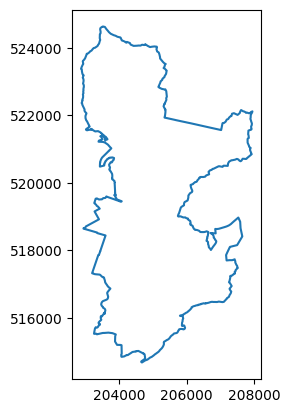

In [ ]:
import geopandas as gpd

# 1) 동 경계 불러오기 (EPSG:4326 → 투영좌표계(e.g. EPSG:5179)로 변환)
fp = "/home/nute11a/workspace/PBL/SUWON/code/data/origin/LARD_ADM_SECT_SGG_41_202505.shp"
gdf = gpd.read_file(fp, engine="pyogrio")


mask = gdf['SGG_NM'] == '경기도 수원시 영통구'
sgg = gdf[mask]
sgg.to_csv('data/preprocessed/suwon_yeongtong_boundary.csv', index=False, encoding='utf-8')
print(sgg)
sgg.boundary.plot()

In [20]:

# gdf_cctv 의 geometry grid가 sgg 안에 있는지 확인
gdf_cctv = gdf_cctv.set_index("AREA_ID")
gdf_cctv = gdf_cctv.to_crs(sgg.crs)
gdf_cctv = gdf_cctv[gdf_cctv.geometry.within(sgg.geometry.values[0])]
gdf_cctv = gdf_cctv.reset_index()
len(gdf_cctv)

359